# **TensorFlow GPU Testing**

In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.keras.__version__)
print(tf.config.list_physical_devices('GPU'))

2025-10-30 19:21:09.209754: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.20.0
3.11.3
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Business Understanding**

## Tujuan

Membangun model **klasifikasi gambar mineral** yang mampu mengenali jenis mineral (misalnya: quartz, calcite, pyrite, dll.) berdasarkan citra mikroskopis atau makro.

## Pertanyaan Bisnis

* Dapatkah sistem otomatis mengidentifikasi jenis mineral dari gambar batuan?
* Seberapa akurat model tersebut dibandingkan dengan identifikasi manual ahli geologi?
* Apakah model bisa membantu percepatan proses eksplorasi mineral?

## Output Bisnis

* Model klasifikasi gambar mineral.
* Dashboard prediksi (opsional).
* Evaluasi akurasi dan confusion matrix untuk interpretasi hasil.

# **Data Understanding**

## **Exploratory Data Analysis**

### **Library Import**

In [2]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import matplotlib.pyplot as plt

In [3]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [4]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

### **Data Splitting**

In [ ]:
# import splitfolders

# # folder input = dataset mentah
# input_folder = "../data/01_raw/mineral-dataset-combined/"

# # output = folder hasil split
# output_folder = "../data/01_raw/mineral-dataset-split/"

# # rasio train, val, test (misal 80-10-10)
# splitfolders.ratio(
#     input_folder,
#     output=output_folder,
#     seed=42,
#     ratio=(.8, .2),
#     group_prefix=None, # buat sequence dataset
#     move=False # kalau True, file dipindah, kalau False, disalin
# )


Copying files: 31286 files [00:17, 1807.26 files/s]


### **Data Loading**

In [5]:
DATA_DIR = "../data/01_raw/mineral-dataset-split/val/"

def load_image_info(data_dir):
    info_list = []
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                path = os.path.join(root, file)
                label = os.path.basename(root)  # asumsi folder = label
                info_list.append({'path': path, 'label': label})
    return pd.DataFrame(info_list)

df = load_image_info(DATA_DIR)
print(f"Jumlah total gambar: {len(df)}")
df.head()

Jumlah total gambar: 6260


,path,label
0,../data/01_raw/mineral-dataset-split/val/gem/1...,gem
1,../data/01_raw/mineral-dataset-split/val/gem/5...,gem
2,../data/01_raw/mineral-dataset-split/val/gem/1...,gem
3,../data/01_raw/mineral-dataset-split/val/gem/5...,gem
4,../data/01_raw/mineral-dataset-split/val/gem/5...,gem


### **Analisis Dimensi dan Ukuran**

In [6]:
def get_image_stats(path):
    try:
        img = Image.open(path)
        w, h = img.size
        aspect = round(w / h, 2)
        return w, h, aspect
    except:
        return None, None, None

df[['width', 'height', 'aspect_ratio']] = df['path'].apply(
    lambda x: pd.Series(get_image_stats(x))
)

print(df.describe())

             width       height  aspect_ratio
count  6260.000000  6260.000000   6260.000000
mean    456.023482   370.885942      1.261399
std     264.149219   210.146509      0.473849
min      35.000000    27.000000      0.160000
25%     187.000000   169.000000      0.980000
50%     455.000000   369.000000      1.190000
75%     683.000000   524.000000      1.450000
max    1022.000000  1016.000000     12.420000


In [7]:
df.head()

,path,label,width,height,aspect_ratio
0,../data/01_raw/mineral-dataset-split/val/gem/1...,gem,433.0,547.0,0.79
1,../data/01_raw/mineral-dataset-split/val/gem/5...,gem,422.0,372.0,1.13
2,../data/01_raw/mineral-dataset-split/val/gem/1...,gem,795.0,523.0,1.52
3,../data/01_raw/mineral-dataset-split/val/gem/5...,gem,969.0,633.0,1.53
4,../data/01_raw/mineral-dataset-split/val/gem/5...,gem,143.0,98.0,1.46


#### **width (lebar gambar)**

* **Rata-rata (mean):** 456 px
* **Std dev (std):** 264 px → cukup bervariasi ukurannya
* **Min:** 35 px
* **Max:** 1022 px
  Ada gambar yang kecil banget (35 px) dan yang besar (1022 px).

#### **height (tinggi gambar)**

* **Rata-rata:** 371 px
* **Std dev:** 210 px
* **Min:** 27 px
* **Max:** 1016 px
  Jadi ukuran gambar juga bervariasi dari kecil sampai besar.

#### **aspect (2.0 semua)**

* Semua nilainya **2.0**
  Ini berarti **nggak bervariasi** — mungkin cuma label, atau placeholder angka kelas.
  Kalau ini seharusnya rasio (width/height), maka datanya salah kolom.

#### **aspect_ratio (width/height)**

* **Rata-rata:** 1.26 → artinya gambar lebih lebar daripada tinggi (landscape)
* **Min:** 0.16 → gambar sangat tinggi (portrait ekstrem)
* **Max:** 12.42 → gambar sangat lebar (panorama)
* **Std dev:** 0.47 → variasi bentuknya lumayan besar

### **Data Checking Color**

In [8]:
def get_color_stats(path):
    try:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mean_rgb = img.mean(axis=(0,1))
        brightness = np.mean(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY))
        contrast = img.std()
        return mean_rgb[0], mean_rgb[1], mean_rgb[2], brightness, contrast
    except:
        return None, None, None, None, None


In [9]:
df[['mean_R', 'mean_G', 'mean_B', 'brightness', 'contrast']] = df['path'].apply(
    lambda x: pd.Series(get_color_stats(x))
)

In [10]:
df[["mean_R", "mean_G", "mean_B", "brightness", "contrast"]].describe()

,mean_R,mean_G,mean_B,brightness,contrast
count,6260.000000,6260.000000,6260.000000,6260.000000,6260.000000
mean,137.696451,130.871856,118.436031,131.498147,64.315499
std,37.253984,36.026412,36.633592,35.848868,16.692763
min,26.376560,21.051418,14.444882,21.911957,9.996799
25%,113.277862,107.084018,95.317678,108.139009,52.558736
50%,139.396099,133.051830,120.342628,133.825208,65.215640
75%,163.317378,155.654638,142.493332,156.038012,76.987542
max,246.513201,246.543518,241.999406,245.998138,111.873893


#### **mean_R / mean_G / mean_B**

* Rata-rata R ≈ **137.7**, G ≈ **130.9**, B ≈ **118.4**
  → artinya gambar-gambar sedikit **bernuansa kemerahan** (Red > Green > Blue).
* **std ≈ 36** → variasi warna antar gambar cukup tinggi.
* Nilai minimum sekitar 20-an dan maksimum sekitar 240-an → brightness range-nya luas.

---

#### **brightness**

* **Rata-rata:** 131.5 → sedang (di tengah antara 0–255).
* **Min:** 21.9 → ada gambar yang sangat gelap.
* **Max:** 246 → ada juga yang sangat terang.
* **Std:** 35.8 → perbedaan kecerahan antar gambar cukup besar.

 Artinya dataset berisi gambar yang sangat beragam dari segi pencahayaan — bagus untuk generalisasi model, tapi mungkin perlu **normalisasi brightness** saat preprocessing.

---

#### **contrast**

* **Rata-rata:** 64.3
* **Std:** 16.7 → cukup bervariasi.
* **Min:** 9.99 → ada gambar yang sangat “flat” (kontras rendah).
* **Max:** 111.87 → ada gambar dengan kontras tinggi banget.

 Bisa jadi dataset punya variasi **pencahayaan ekstrem** — ini bisa bikin training model susah kalau gak dinormalisasi.

#### **Kesimpulan Sementara Untuk Analisis Warna**

* Warna dominan: **merah sedikit lebih tinggi** dari hijau & biru.
* Dataset punya **variasi warna, kecerahan, dan kontras** yang lebar.
* **Perlu preprocessing** (misal: histogram equalization, brightness normalization, atau color standardization) biar model gak bias ke kondisi pencahayaan tertentu.

### **Data Checking**

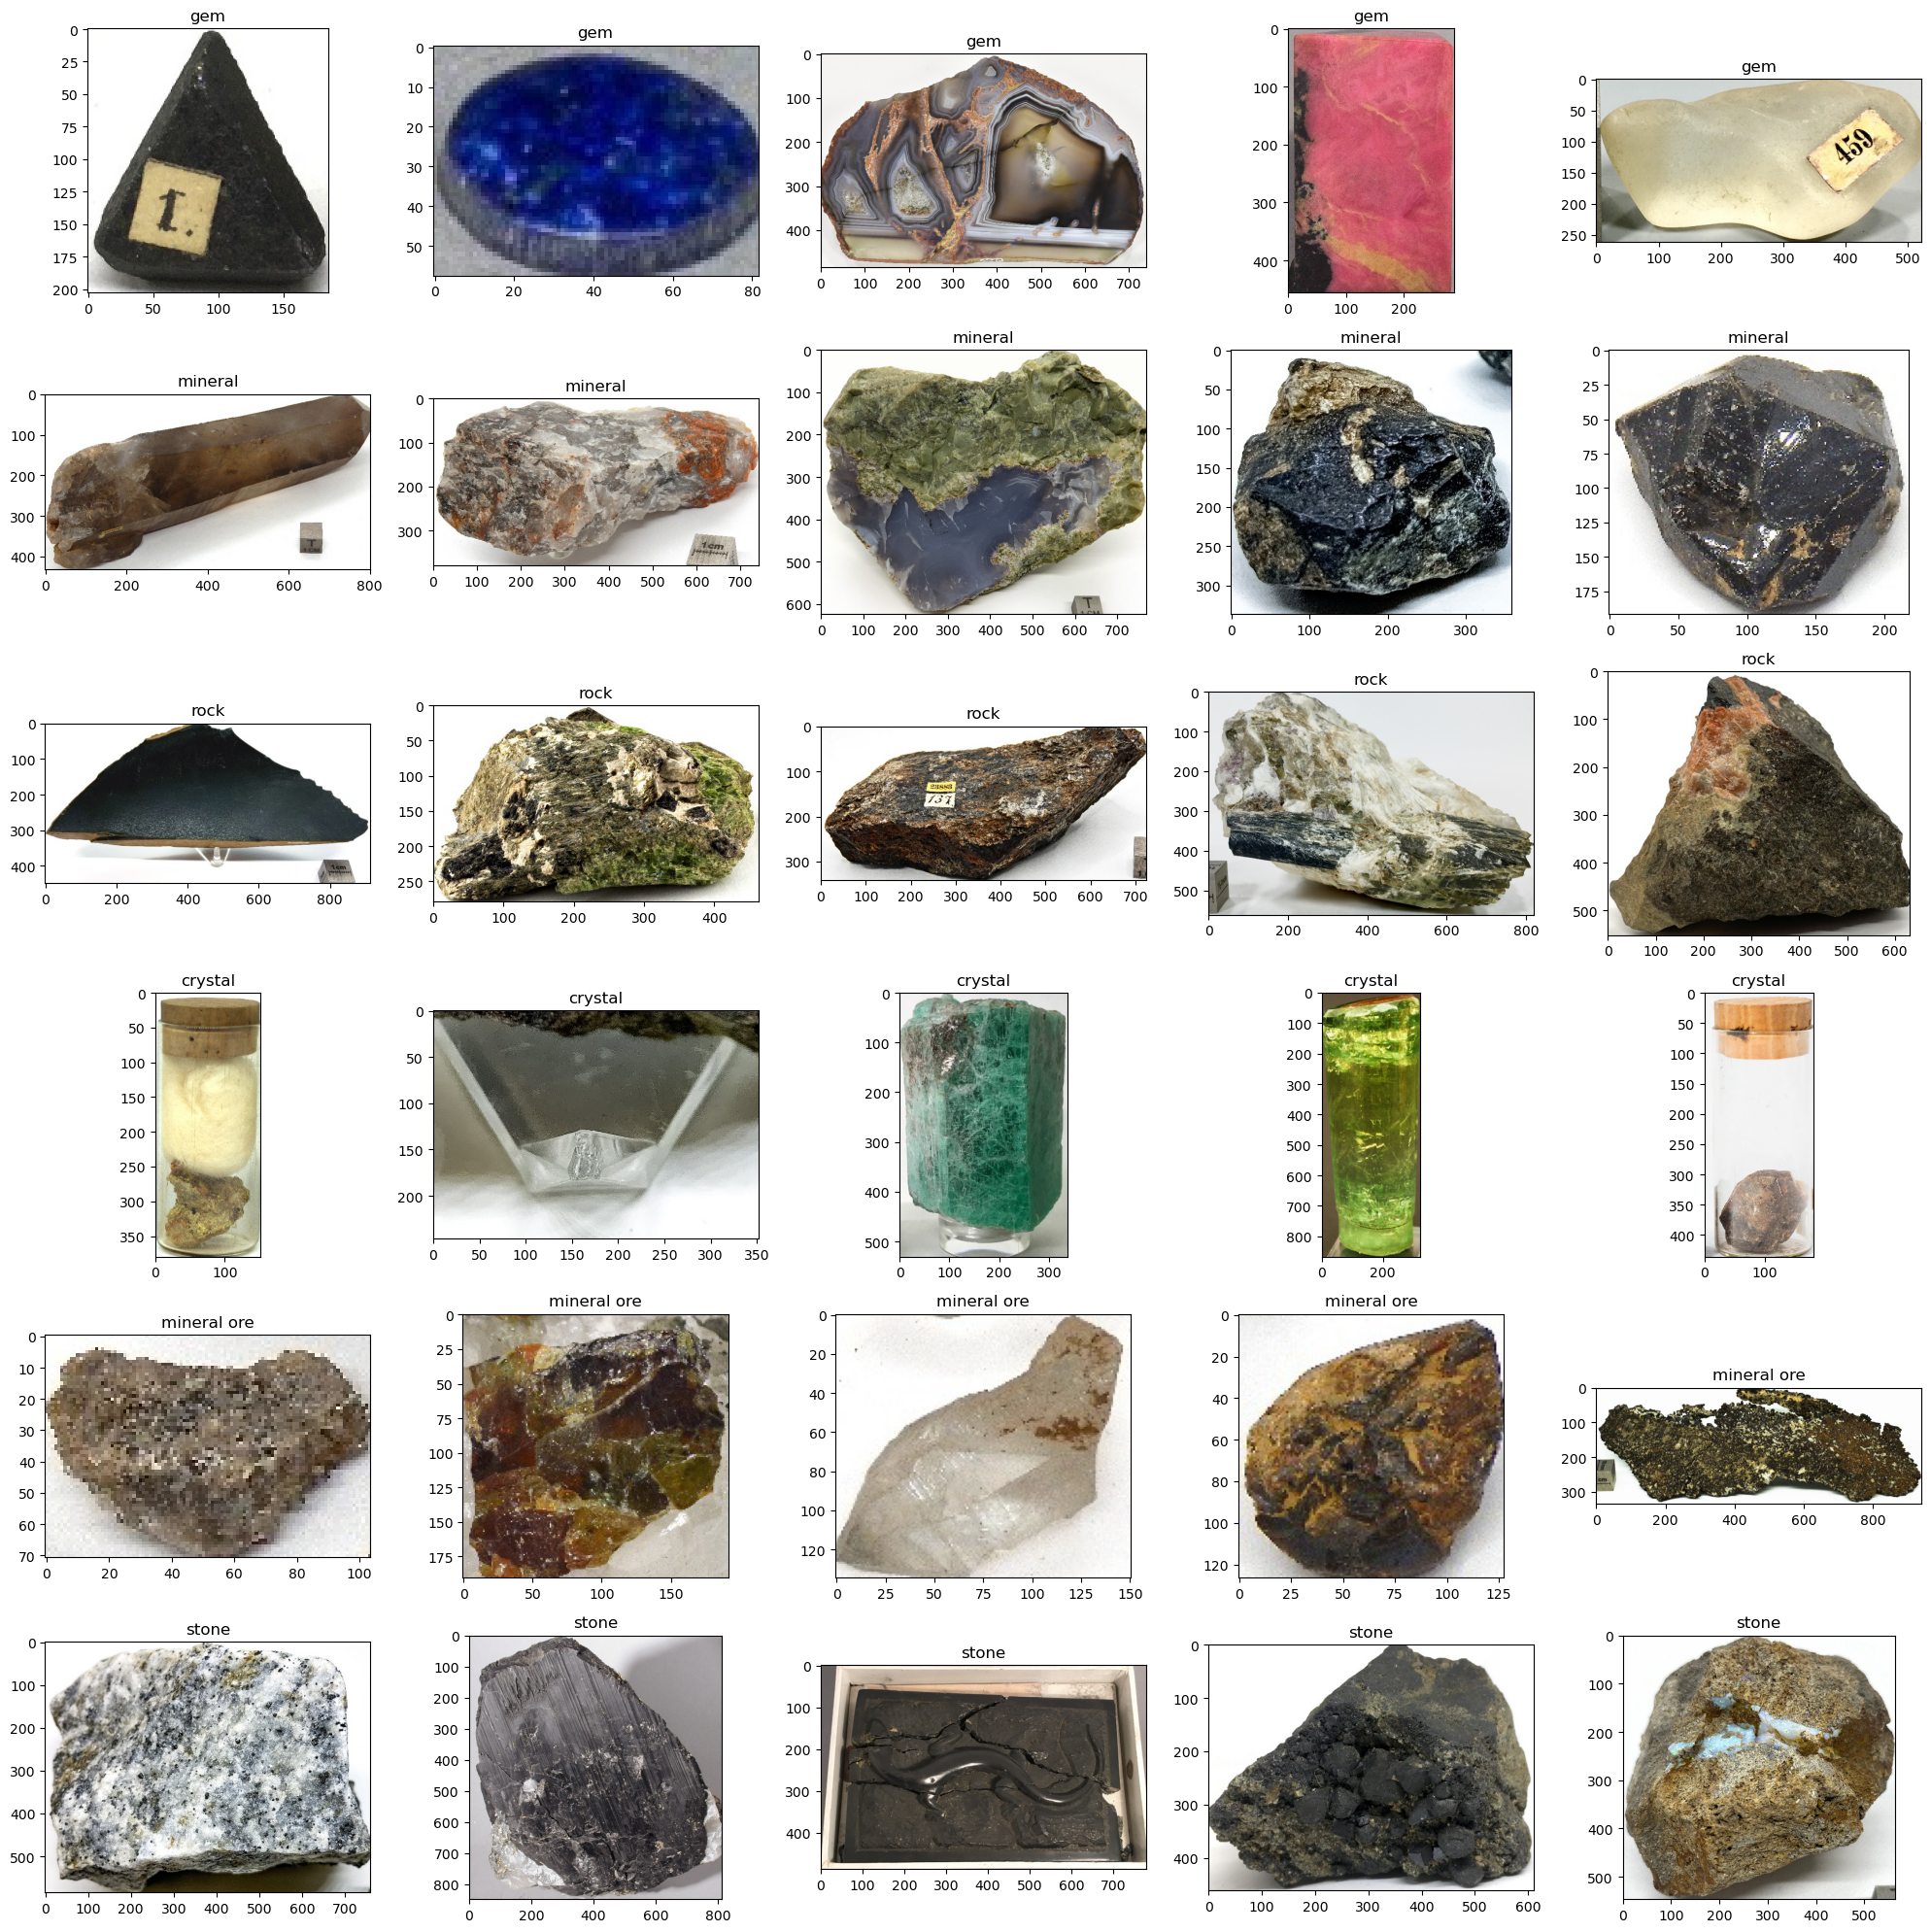

In [11]:
mineral_image = {}

path = "../data/01_raw/mineral-dataset-split/val/"
for i in os.listdir(path):
    mineral_image[i] = os.listdir(os.path.join(path, i))

fig, axs = plt.subplots(len(mineral_image.keys()), 5, figsize=(20, 20))

for i, class_name in enumerate(os.listdir(path)):
    images = np.random.choice(mineral_image[class_name], 5, replace=False)

    for j, imaga_name in enumerate(images):
        img_path = os.path.join(path, class_name, imaga_name)
        img = Image.open(img_path)
        axs[i][j].imshow(img)
        axs[i][j].set_title(class_name)

plt.tight_layout()
plt.show()

### **Distribusi Label dan Dimensi**

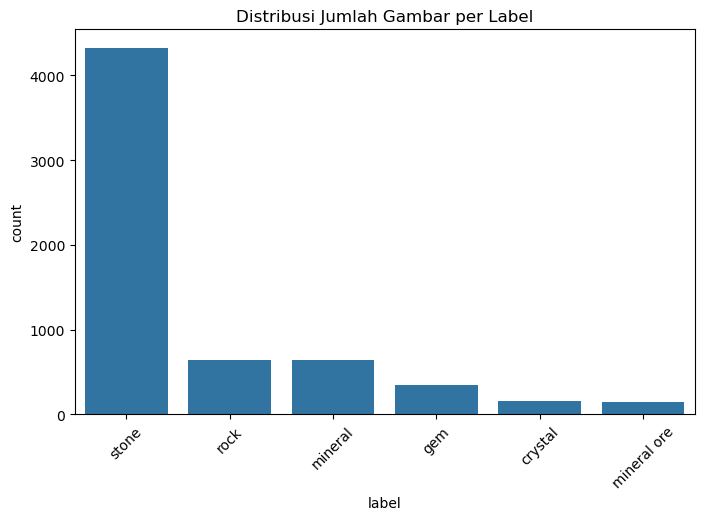

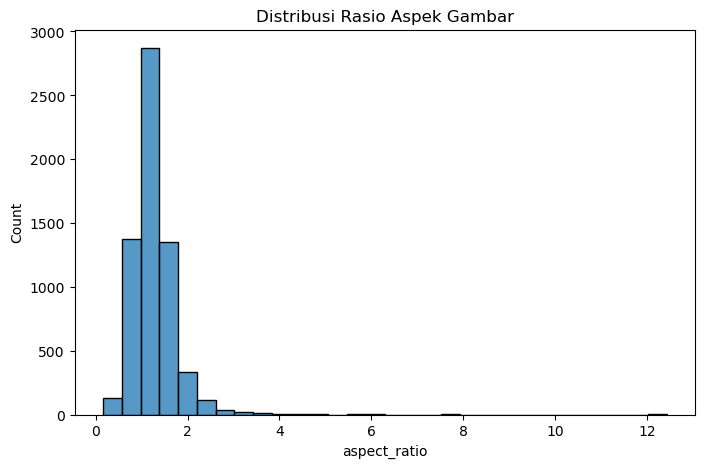

In [12]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title("Distribusi Jumlah Gambar per Label")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['aspect_ratio'], bins=30)
plt.title("Distribusi Rasio Aspek Gambar")
plt.show()

### **Checking Outliers**

#### **Mengecek Resolusi ekstreme**

In [13]:
min_w, max_w = df['width'].min(), df['width'].max()
print(f"Ukuran terkecil: {min_w}px, terbesar: {max_w}px")

Ukuran terkecil: 35.0px, terbesar: 1022.0px


#### **Mengecek Gambar Corrupt**

In [14]:
corrupt_images = df[df['width'].isnull()]
if len(corrupt_images) > 0:
    print(f"[!] Gambar corrupt ditemukan: {len(corrupt_images)}")
    display(corrupt_images)
    
print("tidak ada gambar corrupt")

tidak ada gambar corrupt


# **Data Preparation**

## **Data Cleaning**

In [15]:
input_dir = "../data/01_raw/mineral-dataset-split/val/"
output_dir = "../data/02_clean/"

min_size = 64
max_aspect_ratio = 4
min_aspect_ratio = 0.3

for label in os.listdir(input_dir):
    in_folder = os.path.join(input_dir, label)
    out_folder = os.path.join(output_dir, label)
    os.makedirs(out_folder, exist_ok=True)

    for img_name in os.listdir(in_folder):
        path = os.path.join(in_folder, img_name)
        img = cv2.imread(path)
        if img is None:
            continue
        
        h, w = img.shape[:2]
        aspect = w / h

        if w >= min_size and h >= min_size and min_aspect_ratio < aspect < max_aspect_ratio:
            cv2.imwrite(os.path.join(out_folder, img_name), img)

## **Resize & Normalisasi Brightness/Contrast**

In [16]:
def preprocess_image(img):
    # Resize ke 224x224
    img = cv2.resize(img, (224, 224))
    # Konversi ke LAB (biar bisa equalize L channel aja)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    # Balik ke RGB
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return img

In [19]:
input_dir = "../data/02_clean/"
output_dir = "../data/03_preprocessed/"

for label in os.listdir(input_dir):
    in_folder = os.path.join(input_dir, label)
    out_folder = os.path.join(output_dir, label)
    os.makedirs(out_folder, exist_ok=True)

    for img_name in os.listdir(in_folder):
        img_path = os.path.join(in_folder, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        processed = preprocess_image(img)
        cv2.imwrite(os.path.join(out_folder, img_name), processed)


## **Augmentasi Kelas Minoritas (OpenCV)**

In [25]:
import random
from skimage.transform import rotate, AffineTransform, warp
from skimage.exposure import adjust_gamma

def rotate_image(img, angle=None):
    if angle is None:
        angle = random.uniform(-25, 25)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    rotated = rotate(img, angle, mode="wrap")
    return rotated

def add_brightness(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    gamma = random.uniform(0.5, 1.5)
    bright = adjust_gamma(img, gamma)
    return bright

def blur_image(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    return blur

def shear_image(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    transform = AffineTransform(shear=random.uniform(-0.2, 0.2))
    shear = warp(img, transform, mode="wrap")
    return shear

def warp_shift(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    transform = AffineTransform(translation=(random.randint(-20, 20), random.randint(-20, 20)))
    warp_img = warp(img, transform, mode="wrap")
    return warp_img

def flip_horizontal(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    return np.fliplr(img)

def flip_vertical(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    return np.flipud(img)

augment_funcs = [
    rotate_image,
    add_brightness,
    blur_image,
    shear_image,
    warp_shift,
    flip_horizontal,
    flip_vertical,
]

In [ ]:
input_dir = "../data/03_preprocessed"
output_dir = "../data/04_augmented"
os.makedirs(output_dir, exist_ok=True)

minor_classes = ["rock", "gem", "crystal", "mineral", "mineral ore"]

for cls in minor_classes:
    in_folder = os.path.join(input_dir, cls)
    out_folder = os.path.join(output_dir, cls)
    os.makedirs(out_folder, exist_ok=True)

    for img_name in os.listdir(in_folder):
        img_path = os.path.join(in_folder, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        # Simpan original
        cv2.imwrite(os.path.join(out_folder, img_name), img)

        # Simpan versi augmentasi
        for func in augment_funcs:
            aug = func(img)
            aug = (aug * 255).astype(np.uint8)
            new_name = f"{os.path.splitext(img_name)[0]}_{func.__name__}.jpg"
            cv2.imwrite(os.path.join(out_folder, new_name), aug)


## **Gabungkan Semua Dataset (Mayoritas + Augmentasi Minoritas)**

In [28]:
final_dir = "../data/05_final"

# copy kelas mayoritas
shutil.copytree("../data/03_preprocessed/stone", f"{final_dir}/stone", dirs_exist_ok=True)

# copy hasil augmentasi minoritas
shutil.copytree("../data/04_augmented", final_dir, dirs_exist_ok=True)

'../data/05_final'

## **Cek Distribusi Label setelah Augmentasi**

In [29]:
DATA_FINAL = "../data/05_final/"

def load_image_info(data_dir):
    info_list = []
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                path = os.path.join(root, file)
                label = os.path.basename(root)  # asumsi folder = label
                info_list.append({'path': path, 'label': label})
    return pd.DataFrame(info_list)

df_final = load_image_info(DATA_FINAL)
print(f"Jumlah total gambar: {len(df_final)}")
df_final.head()

Jumlah total gambar: 19191


,path,label
0,../data/05_final/gem/5_PDK_5_198_0_shear_image...,gem
1,../data/05_final/gem/1_syst_1_51210_1_51210_0.jpg,gem
2,../data/05_final/gem/7_stepanov_FMM_7_3646_10_...,gem
3,../data/05_final/gem/5_PDK_5_229_0_blur_image.jpg,gem
4,../data/05_final/gem/1_syst_1_54186_IMG_4955_1...,gem


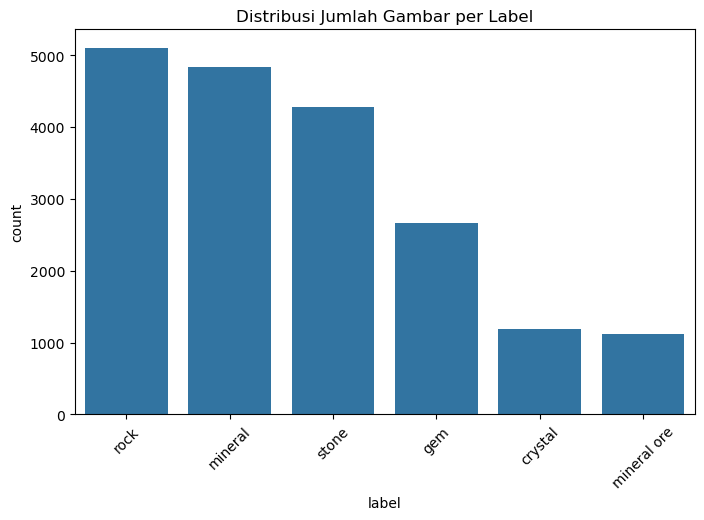

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_final, x='label', order=df_final['label'].value_counts().index)
plt.title("Distribusi Jumlah Gambar per Label")
plt.xticks(rotation=45)
plt.show()

Masih ada kelas minoritas, tetapi sudah jauh lebih banyak daripada sebelumnya. solusi selanjutnya mungkin akan menerapkan class weight

## **Tensorflow Dataset Load**

In [32]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/05_final",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/05_final",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)


Found 19191 files belonging to 6 classes.
Using 15353 files for training.


I0000 00:00:1761828626.593634    3512 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2286 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 8.6


Found 19191 files belonging to 6 classes.
Using 3838 files for validation.


## **Handling Imbalanced Classes**

In [33]:
import numpy as np
from collections import Counter

# Ambil label dari dataset
labels = np.concatenate([y for x, y in train_ds], axis=0)
class_counts = Counter(labels)
total = sum(class_counts.values())

class_weights = {
    i: total / (len(class_counts) * c)
    for i, c in class_counts.items()
}
print(class_weights)


{np.int32(4): 0.6288604898828541, np.int32(5): 0.7514929025942242, np.int32(1): 1.2047237915881983, np.int32(0): 2.657147802007615, np.int32(2): 0.6608557162534435, np.int32(3): 2.781340579710145}


2025-10-30 19:51:45.018515: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
